Coefficient: 1.3139999999999998


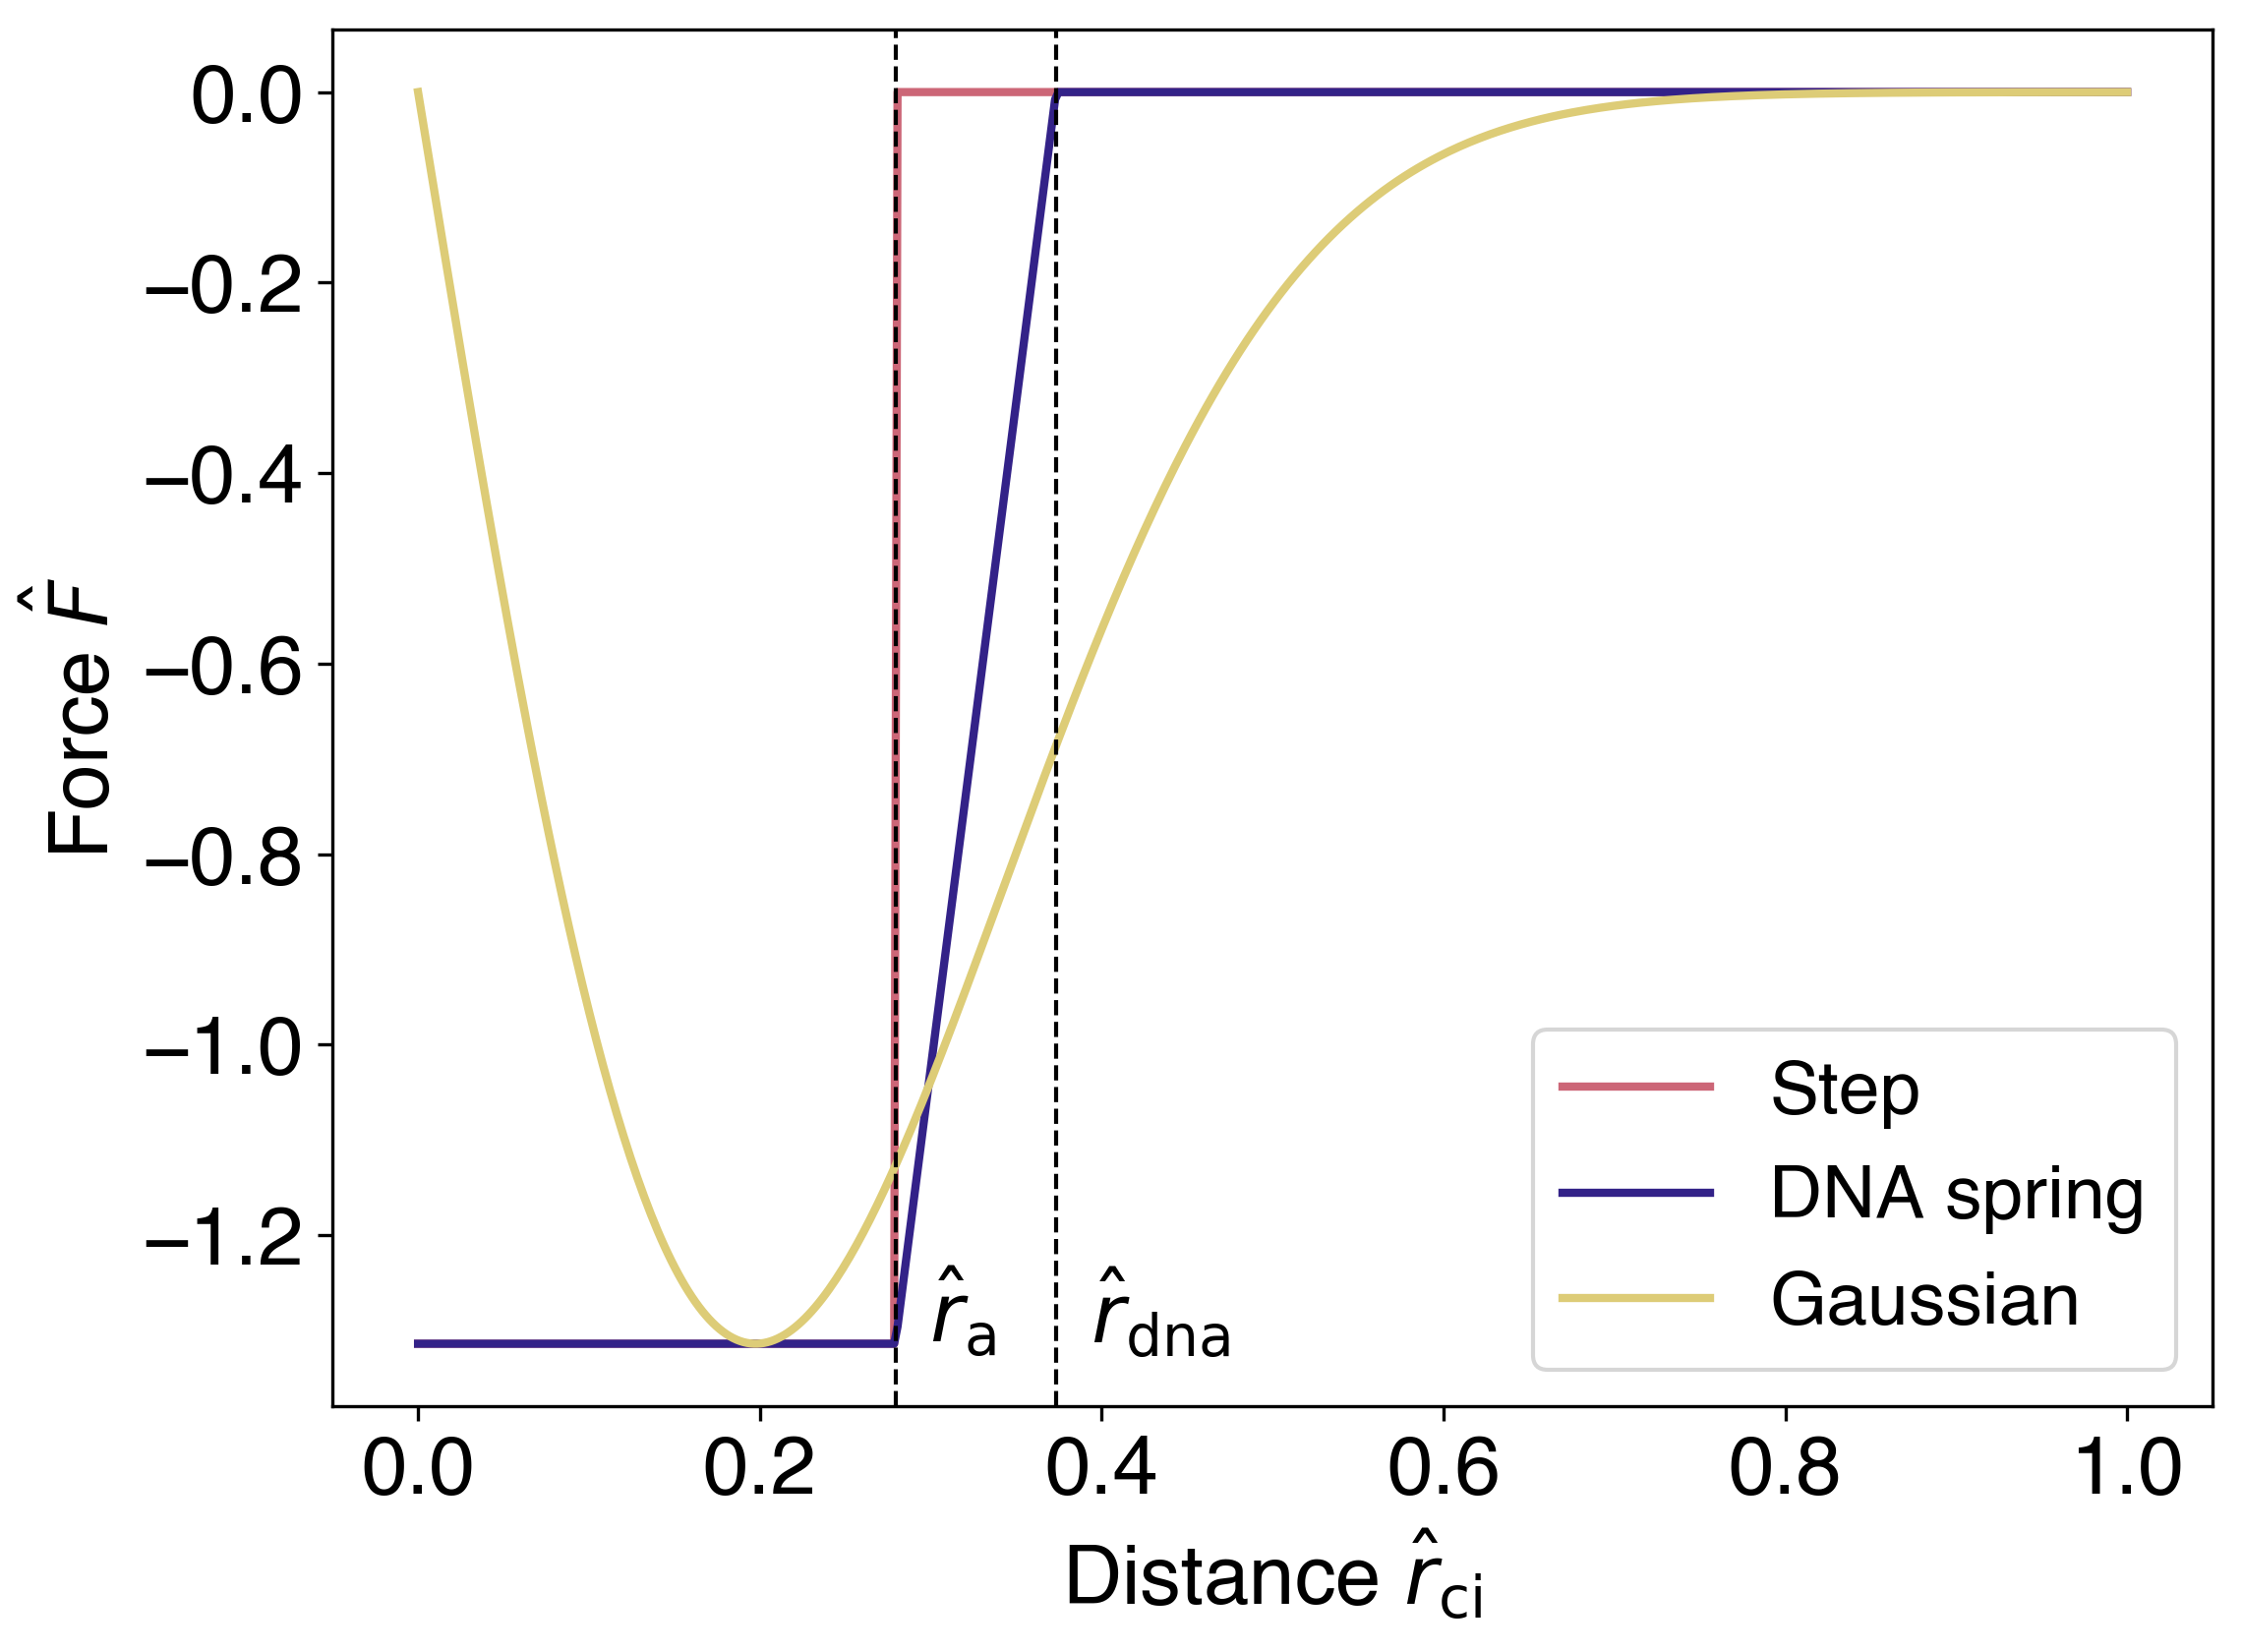

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('styles/my_style.mplstyle')

def dna_force_gaussian(epsilon, r, r_a):
    return -2 * epsilon * r * np.exp(-(r**2)/(r_a**2)) / (r_a**2)

def dna_force(f, r, r_a):
    if r < r_a:
        return -f
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0

r = 0.59
d = 0.025
l = 0.010
r_a = np.sqrt(2 * r * d / (1 + d/r)**2)/r
r_dna = np.sqrt((d+2*l)*(2*r+2*l))/(r*(1+(2*l+d/2)/r))

f = 6.57e-4 # in µN
epsilon = np.sqrt(np.exp(1)/2) * r_a * f 

k_cargo = 1.0e-3
v = 0.5
tau = r/v

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

ax.axvline(r_a, color='black', lw=1, ls='--')
ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -f*coefficient, '$\hat{r}_\mathrm{a}$')
ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\hat{r}_\mathrm{ci}$')
ax.set_ylabel('Force $\hat{F}$')
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')

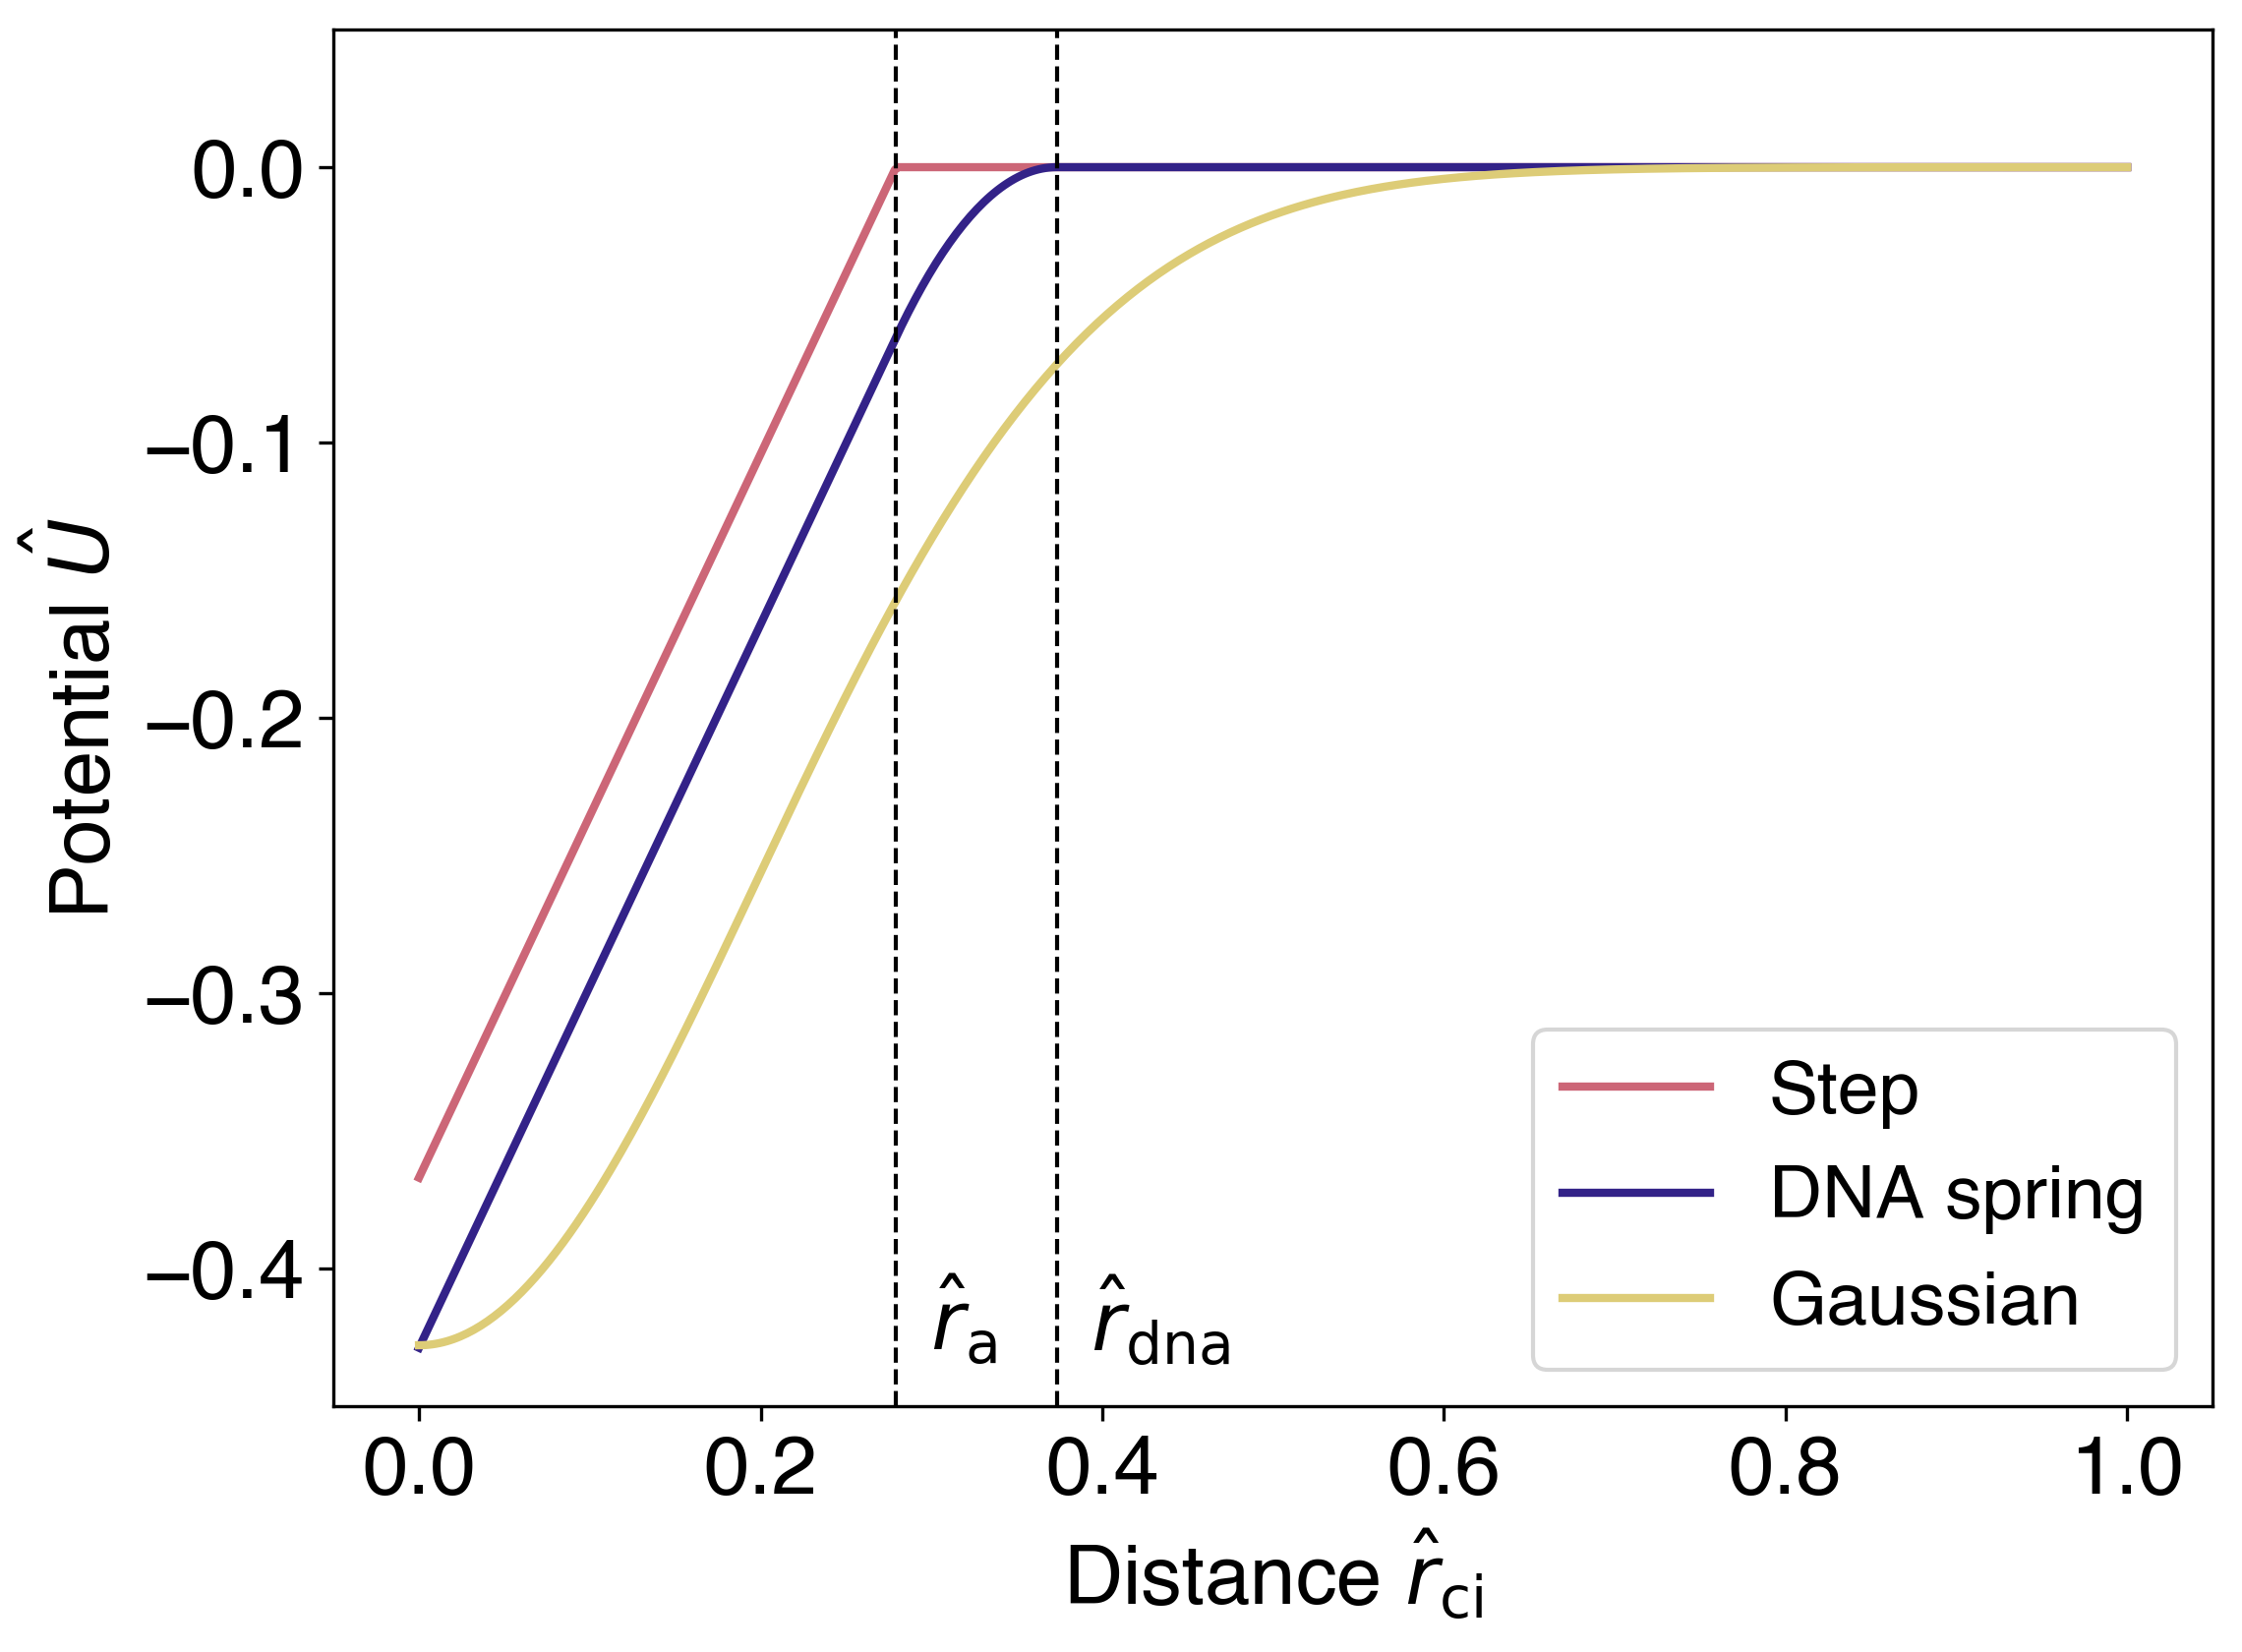

In [40]:
def potential_gaussian(epsilon, r, r_a):
    return -epsilon * np.exp(-(r**2)/(r_a**2))

def potential_step(f, r, r_a):
    if r < r_a:
        return f * r - f * r_a
    else:
        return 0
    
def potential_spring(f, r, r_a, r_dna):
    if r < r_a:
        return f * r - f * (r_a+r_dna)/2
    elif r_a <= r < r_dna:
        return -f * (r_a + (r_dna - r)**2 / (2 * (r_dna - r_a))) + f * r_a
    else:
        return 0
    
fig, ax = plt.subplots()
ax.plot(distances, [potential_step(f*coefficient, r, r_a) for r in distances], label='Step')
ax.plot(distances, [potential_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [potential_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')
ax.axvline(r_a, color='black', lw=1, ls='--')
ax.axvline(r_dna, color='black', lw=1, ls='--')
ax.text(r_a + 0.02, -0.43, '$\hat{r}_\mathrm{a}$')
ax.text(r_dna + 0.02, -0.43, '$\hat{r}_\mathrm{dna}$')
ax.set_xlabel('Distance $\hat{r}_\mathrm{ci}$')
ax.set_ylabel('Potential $\hat{U}$')

ax.set_ylim(-0.45, 0.05)

ax.legend()

fig.savefig('../figures/dna_potential_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_potential_comparison.pdf', bbox_inches='tight')